In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [144]:
#n must be between 14 and 24, inclusive.
for n in range(18, 25) :
    file_off = "total_offense/NCAA_total_offense_" + str(n-1) + "-" + str(n) + ".csv"
    file_def = "total_defense/NCAA_total_defense_" + str(n-1) + "-" + str(n) + ".csv"
    df_off = pd.read_csv(file_off)
    df_def = pd.read_csv(file_def)

    df = df_off.merge(df_def, on="Team", how="outer", indicator=True, suffixes=["_offense", "_defense"])

    temp = df.Team.str.split("(", expand=True)
    temp[1] = temp[1].str.replace(")", "")
    temp.drop(2, axis=1)

    df.Team = temp[0].str.strip()
    df["Conference"] = temp[1].str.strip(")")

    df.Team = df.Team.str.replace("St.", "State")

    df["Win_Loss"] = df["W-L_offense"]
    df = df.drop(["W-L_offense", "W-L_defense"], axis=1)

    df["Games"] = df.G_offense
    df = df.drop(["G_offense", "G_defense"], axis=1)

    year = 2000 + n - 1
    df["starting_year"] = year

    df.to_csv("team_stats_" + str(year) + ".csv")

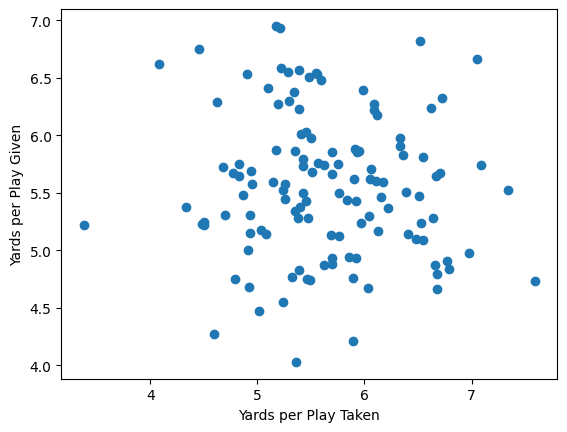

In [131]:
plt.scatter(df["Yds/Play_offense"], df["Yds/Play_defense"])
plt.xlabel("Yards per Play Taken")
plt.ylabel("Yards per Play Given")
plt.show()

In [114]:
df.sort_values(by="Rank_offense")[["Team", "Rank_offense", "Rank_defense", "Yds/Play_offense","Yds/Play_defense"]]

,Team,Rank_offense,Rank_defense,Yds/Play_offense,Yds/Play_defense
54,Michigan State,80,2,5.40,4.04
28,Florida State,6,3,7.67,4.09
46,Louisville,28,1,6.70,4.20
114,Virginia Tech,101,4,5.00,4.55
111,Utah State,59,12,5.37,4.55
...,...,...,...,...,...
103,UAB,78,116,5.84,7.21
64,New Mexico,53,119,6.48,7.42
109,UTEP,103,107,5.05,7.43
24,Eastern Mich.,109,118,5.16,7.61


,Rank_offense,Team,Plays_offense,YDS_offense,Yds/Play_offense,Off TDs_offense,TDs,YPG_offense,Rank_defense,Plays_defense,YDS_defense,Yds/Play_defense,Off TDs_defense,Opp TDs,YPG_defense,_merge,Conference,Win_Loss,Games
0,91,Air Force,811,"4,411",5.44,38,38,367.6,114,918,"5,883",6.41,67,67,490.3,both,Mountain West,2-10,12
1,106,Akron,837,"4,104",4.90,30,31,342.0,59,865,"4,764",5.51,43,44,397.0,both,MAC,5-7,12
2,33,Alabama,826,"5,903",7.15,58,65,454.1,5,771,"3,725",4.83,21,23,286.5,both,SEC,11-2,13
3,31,Arizona,"1,030","5,960",5.79,52,57,458.5,62,991,"5,214",5.26,38,39,401.1,both,Pac-12,8-5,13
4,32,Arizona State,"1,102","6,402",5.81,64,69,457.3,42,942,"5,213",5.53,45,48,372.4,both,Pac-12,10-4,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,62,West Virginia,892,"4,932",5.53,34,38,411.0,101,920,"5,460",5.93,47,48,455.0,both,Big 12,4-8,12
119,30,Western Ky.,875,"5,502",6.29,46,47,458.5,14,763,"4,070",5.33,34,37,339.2,both,Sun Belt,8-4,12
120,110,Western Mich.,827,"3,926",4.75,22,23,327.2,85,865,"5,030",5.82,46,55,419.2,both,MAC,1-11,12
121,18,Wisconsin,912,"6,251",6.85,57,59,480.8,7,839,"3,966",4.73,24,25,305.1,both,Big Ten,9-4,13


In [118]:
df.drop("_merge", axis=1)

,Rank_offense,Team,Plays_offense,YDS_offense,Yds/Play_offense,Off TDs_offense,TDs,YPG_offense,Rank_defense,Plays_defense,YDS_defense,Yds/Play_defense,Off TDs_defense,Opp TDs,YPG_defense,Conference,Win_Loss,Games
0,91,Air Force,811,"4,411",5.44,38,38,367.6,114,918,"5,883",6.41,67,67,490.3,Mountain West,2-10,12
1,106,Akron,837,"4,104",4.90,30,31,342.0,59,865,"4,764",5.51,43,44,397.0,MAC,5-7,12
2,33,Alabama,826,"5,903",7.15,58,65,454.1,5,771,"3,725",4.83,21,23,286.5,SEC,11-2,13
3,31,Arizona,"1,030","5,960",5.79,52,57,458.5,62,991,"5,214",5.26,38,39,401.1,Pac-12,8-5,13
4,32,Arizona State,"1,102","6,402",5.81,64,69,457.3,42,942,"5,213",5.53,45,48,372.4,Pac-12,10-4,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,62,West Virginia,892,"4,932",5.53,34,38,411.0,101,920,"5,460",5.93,47,48,455.0,Big 12,4-8,12
119,30,Western Ky.,875,"5,502",6.29,46,47,458.5,14,763,"4,070",5.33,34,37,339.2,Sun Belt,8-4,12
120,110,Western Mich.,827,"3,926",4.75,22,23,327.2,85,865,"5,030",5.82,46,55,419.2,MAC,1-11,12
121,18,Wisconsin,912,"6,251",6.85,57,59,480.8,7,839,"3,966",4.73,24,25,305.1,Big Ten,9-4,13


In [120]:
df["starting_year"] = 2013

In [121]:
df

,Rank_offense,Team,Plays_offense,YDS_offense,Yds/Play_offense,Off TDs_offense,TDs,YPG_offense,Rank_defense,Plays_defense,YDS_defense,Yds/Play_defense,Off TDs_defense,Opp TDs,YPG_defense,_merge,Conference,Win_Loss,Games,starting_year
0,91,Air Force,811,"4,411",5.44,38,38,367.6,114,918,"5,883",6.41,67,67,490.3,both,Mountain West,2-10,12,2013
1,106,Akron,837,"4,104",4.90,30,31,342.0,59,865,"4,764",5.51,43,44,397.0,both,MAC,5-7,12,2013
2,33,Alabama,826,"5,903",7.15,58,65,454.1,5,771,"3,725",4.83,21,23,286.5,both,SEC,11-2,13,2013
3,31,Arizona,"1,030","5,960",5.79,52,57,458.5,62,991,"5,214",5.26,38,39,401.1,both,Pac-12,8-5,13,2013
4,32,Arizona State,"1,102","6,402",5.81,64,69,457.3,42,942,"5,213",5.53,45,48,372.4,both,Pac-12,10-4,14,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,62,West Virginia,892,"4,932",5.53,34,38,411.0,101,920,"5,460",5.93,47,48,455.0,both,Big 12,4-8,12,2013
119,30,Western Ky.,875,"5,502",6.29,46,47,458.5,14,763,"4,070",5.33,34,37,339.2,both,Sun Belt,8-4,12,2013
120,110,Western Mich.,827,"3,926",4.75,22,23,327.2,85,865,"5,030",5.82,46,55,419.2,both,MAC,1-11,12,2013
121,18,Wisconsin,912,"6,251",6.85,57,59,480.8,7,839,"3,966",4.73,24,25,305.1,both,Big Ten,9-4,13,2013


In [122]:
df.to_csv("team_stats_2013.csv")

In [141]:
df_off = pd.read_csv("total_offense/NCAA_total_offense_15-16.csv")

In [140]:
df_off

,Rank,Team,G,W-L,Plays,YDS,Yds/Play,Off TDs,TDs,YPG
1.0,Texas Tech (Big 12),12,5-7,1,42,6,774.00,6.50,69.0,564.5
2.0,Oklahoma (Big 12),13,11-2,957,7,212,7.54,73.00,554.8,NaN
3.0,Louisville (ACC),13,9-4,961,6,925,7.21,69.00,532.7,NaN
4.0,Tulsa (AAC),13,10-3,1,114,6,851.00,6.15,66.0,527.0
5.0,Western Ky. (C-USA),14,11-3,958,7,324,7.65,77.00,523.1,NaN
...,...,...,...,...,...,...,...,...,...,...
125.0,Kent St. (MAC),12,3-9,765,3,710,4.85,26.00,309.2,NaN
126.0,Texas St. (Sun Belt),12,2-10,841,3,628,4.31,27.00,302.3,NaN
127.0,Boston College (ACC),13,7-6,862,3,807,4.42,30.00,292.8,NaN
128.0,Rutgers (Big Ten),12,2-10,821,3,398,4.14,19.00,283.2,NaN


In [142]:
df_off

,Rank,Team,G,W-L,Plays,YDS,Yds/Play,Off TDs,TDs,YPG
0,1,Baylor (Big 12),13,10-3,"1,103","8,011",7.26,85,49,616.2
1,2,Texas Tech (Big 12),13,7-6,"1,084","7,533",6.95,73,77,579.5
2,3,TCU (Big 12),13,11-2,"1,078","7,317",6.79,65,45,562.8
3,4,Bowling Green (MAC),14,10-4,"1,136","7,655",6.74,81,50,546.8
4,5,Oregon (Pac-12),13,9-4,993,"6,997",7.05,67,62,538.2
...,...,...,...,...,...,...,...,...,...,...
122,123,UConn (AAC),13,6-7,819,"4,034",4.93,24,29,310.3
123,124,Missouri (SEC),12,5-7,770,"3,371",4.38,15,22,280.9
124,125,Boston College (ACC),12,3-9,751,"3,307",4.40,25,19,275.6
125,126,Kent St. (MAC),12,3-9,790,"3,250",4.11,15,40,270.8


In [143]:
file_off

'total_offense/NCAA_total_offense_16-17.csv'